<a href="https://colab.research.google.com/github/Nidhisha00/AI-ML-10days-Internship/blob/main/Day6/CNN_Brain_Tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile

zip_path = "/content/archive (21).zip"
extract_path = "/content/brain_tumor"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

In [ ]:
import os

dataset_path = "/content/brain_tumor/brain_tumor_dataset"

print(os.listdir(dataset_path))

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

In [ ]:
model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 634ms/step - accuracy: 0.6798 - loss: 0.5832 - val_accuracy: 0.7600 - val_loss: 0.5296
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 12s 935ms/step - accuracy: 0.7980 - loss: 0.4823 - val_accuracy: 0.7600 - val_loss: 0.5994
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 15s 450ms/step - accuracy: 0.7833 - loss: 0.4978 - val_accuracy: 0.7200 - val_loss: 0.5234
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 11s 497ms/step - accuracy: 0.8079 - loss: 0.4498 - val_accuracy: 0.7400 - val_loss: 0.5080
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 497ms/step - accuracy: 0.8424 - loss: 0.3905 - val_accuracy: 0.7800 - val_loss: 0.5398
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 484ms/step - accuracy: 0.8818 - loss: 0.3156 - val_accuracy: 0.8000 - val_loss: 0.4715
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 559ms/step - accuracy: 0.8916 - loss: 0.2693 - val_accuracy: 0.7400 - val_loss: 0.4632
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 458ms/step - accuracy: 0.9064 - loss: 0.2128 - val_accuracy

In [ ]:
epochs=15
epochs=20

In [ ]:
loss, accuracy = model.evaluate(validation_generator)

print(f"Validation Accuracy: {accuracy*100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8000 - loss: 0.4565 
Validation Accuracy: 80.00%


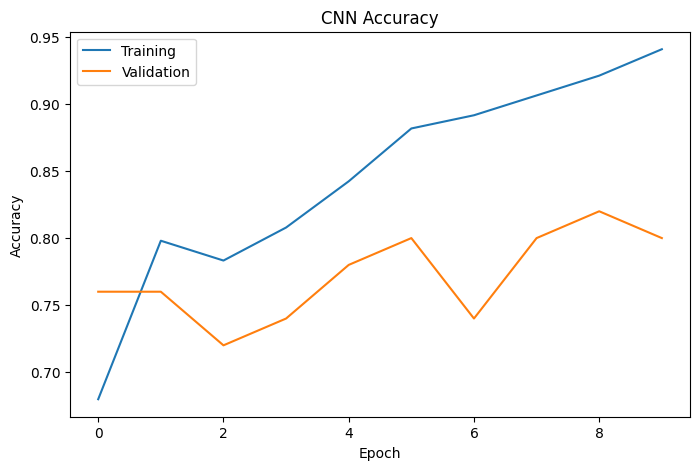

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Training","Validation"])

plt.show()

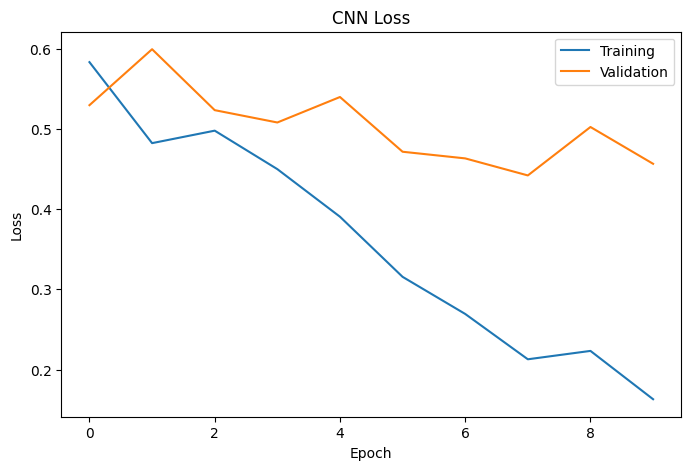

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Training","Validation"])

plt.show()

In [ ]:
validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = (predictions > 0.5).astype(int)

y_true = validation_generator.classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step


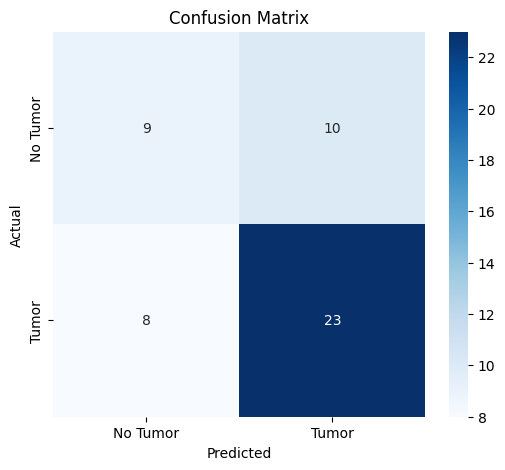

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Tumor","Tumor"],
    yticklabels=["No Tumor","Tumor"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["No Tumor","Tumor"]
    )
)

              precision    recall  f1-score   support

    No Tumor       0.53      0.47      0.50        19
       Tumor       0.70      0.74      0.72        31

    accuracy                           0.64        50
   macro avg       0.61      0.61      0.61        50
weighted avg       0.63      0.64      0.64        50



In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

image_path = "/content/tumor mri.jpg"

img = image.load_img(
    image_path,
    target_size=(128,128)
)

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("🧠 Brain Tumor Detected")
else:
    print("✅ No Brain Tumor Detected")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Y1.jpg'

In [ ]:
model.save("brain_tumor_cnn.h5")

print("Model Saved Successfully!")